#  Projet ML — Prévision du Taux de Change EUR/TND
## Notebook 02 : Préprocessing, Feature Engineering & Modélisation

**Auteurs :** *Ben Selma Hibe & Cherchir Aya*  
**Dataset :** `macro_market_merged.csv` (produit par `01_EDA.ipynb`)  
**Objectif :** Prédire le taux EUR/TND du lendemain en comparant 4 algorithmes : Ridge Regression (linéaire), XGBoost, Random Forest, LightGBM.


---
## 1. Prétraitement des Données (Data Preprocessing)

### Objectif
Nettoyer, encoder et normaliser le dataset avant la modélisation.


In [2]:
# ============================================================
# ÉTAPE 1 : Imports & chargement du dataset fusionné
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Style graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# --- Charger ---
full = pd.read_csv("macro_market_merged.csv", parse_dates=["date"], index_col="date")

# Normaliser les noms de colonnes (supprime accents, espaces → underscore)
def normalize_col(s):
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s.strip().lower().replace(" ", "_")

full.columns = [normalize_col(c) for c in full.columns]

print("=" * 60)
print("DATASET CHARGÉ")
print("=" * 60)
print(f"Shape       : {full.shape}")
print(f"Période     : {full.index.min().date()} → {full.index.max().date()}")
print(f"Colonnes    : {list(full.columns)}")
print(f"\nValeurs manquantes par colonne:")
print(full.isna().sum()[full.isna().sum() > 0])


DATASET CHARGÉ
Shape       : (3653, 10)
Période     : 2015-01-02 → 2025-01-01
Colonnes    : ['balance_commerciale', 'pib', 'taux_interet', 'inflation_daily', 'eur_usd', 'brent_oil', 'gold', 'eur_gbp', 'us_10y_yield', 'msci_em']

Valeurs manquantes par colonne:
Series([], dtype: int64)


In [3]:
# ============================================================
# 1.1 — Ajout de la variable cible EUR/TND
# ============================================================
import yfinance as yf

print("Téléchargement EUR/TND...")
raw = yf.download("EURTND=X", start="2015-01-01", end="2025-01-02",
                  auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

eurtnd = raw["Close"].copy()
eurtnd.name = "eurtnd"
eurtnd.index = pd.to_datetime(eurtnd.index).tz_localize(None)

eurtnd_daily = eurtnd.reindex(full.index).ffill(limit=3)
full["eurtnd"] = eurtnd_daily
full = full.dropna(subset=["eurtnd"])

print(f"Variable cible ajoutée — EUR/TND : {full['eurtnd'].min():.4f} → {full['eurtnd'].max():.4f}")
print(f"Shape après ajout cible : {full.shape}")


Téléchargement EUR/TND...
Variable cible ajoutée — EUR/TND : 2.0706 → 3.4529
Shape après ajout cible : (3652, 11)


In [5]:
# ============================================================
# 1.2 — Nettoyage : Gestion des NaN restants & doublons
# ============================================================

# Doublons sur l'index
dups = full.index.duplicated().sum()
print(f"Doublons d'index : {dups}")
if dups > 0:
    full = full[~full.index.duplicated(keep='first')]

# NaN : on forward-fill les trous < 5 jours (week-ends marchés)
full = full.ffill(limit=5)
full = full.dropna()

print(f"Shape après nettoyage : {full.shape}")
print(f"Valeurs manquantes restantes : {full.isna().sum().sum()}")


Doublons d'index : 0
Shape après nettoyage : (3652, 11)
Valeurs manquantes restantes : 0


---
## 2. Feature Engineering & Sélection

Nous créons des features temporelles riches pour capturer les dépendances des séries temporelles.


In [6]:
# ============================================================
# ÉTAPE 2 : Feature Engineering
# ============================================================

TARGET = "eurtnd"

# Identifier les colonnes de marché pour les lags
LAG_COLS = [c for c in ["eurtnd", "eur_usd", "brent_oil", "gold", "eur_gbp",
                         "us_10y_yield", "msci_em", "balance_commerciale"] if c in full.columns]

# Proxy DXY
full["dxy_proxy"] = 1 / full["eur_usd"]

# --- 2.1 Lags (valeurs décalées) ---
print("Création des lags...")
for col in LAG_COLS:
    full[f"{col}_lag1"]  = full[col].shift(1)
    full[f"{col}_lag3"]  = full[col].shift(3)
    full[f"{col}_lag7"]  = full[col].shift(7)
    full[f"{col}_lag30"] = full[col].shift(30)

# --- 2.2 Statistiques glissantes sur EUR/TND ---
print("Création des moyennes et volatilités glissantes...")
for window in [7, 14, 30]:
    full[f"eurtnd_ma{window}"]  = full["eurtnd"].shift(1).rolling(window).mean()
    full[f"eurtnd_std{window}"] = full["eurtnd"].shift(1).rolling(window).std()

# --- 2.3 Rendements logarithmiques ---
print("Création des rendements log...")
for col in [c for c in ["eurtnd", "eur_usd", "brent_oil", "gold", "msci_em"] if c in full.columns]:
    full[f"{col}_ret1"]  = np.log(full[col] / full[col].shift(1))
    full[f"{col}_ret7"]  = np.log(full[col] / full[col].shift(7))
    full[f"{col}_ret30"] = np.log(full[col] / full[col].shift(30))

# --- 2.4 Features de spread & calendrier ---
taux_col = [c for c in full.columns if "taux" in c]
if taux_col:
    taux_col = taux_col[0]
    print(f"Colonne taux d'intérêt détectée : '{taux_col}'")
    infl_col = [c for c in full.columns if "inflation" in c]
    if infl_col:
        full["rate_inflation_spread"] = full[taux_col] - (full[infl_col[0]] * 100)

full["eur_usd_ma30_dev"] = full["eur_usd"] - full["eur_usd"].shift(1).rolling(30).mean()
full["day_of_week"]      = full.index.dayofweek
full["month"]            = full.index.month
full["quarter"]          = full.index.quarter
full["year_normalized"]  = (full.index.year - 2015) / 10

# --- Drop NaN issus des lags/rolling ---
df = full.dropna()

print(f"\n{'='*50}")
print(f"DATASET FINAL AVEC FEATURES : {df.shape}")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"Features : {df.shape[1] - 1}  (excl. target '{TARGET}')")
print(f"{'='*50}")


Création des lags...
Création des moyennes et volatilités glissantes...
Création des rendements log...
Colonne taux d'intérêt détectée : 'taux_interet'

DATASET FINAL AVEC FEATURES : (3622, 71)
Période : 2015-02-01 → 2025-01-01
Features : 70  (excl. target 'eurtnd')


Top 20 features par |corrélation| avec EUR/TND:
eurtnd_lag1        0.9993
eurtnd_ma7         0.9992
eurtnd_ma14        0.9989
eurtnd_lag3        0.9989
eurtnd_lag7        0.9984
eurtnd_ma30        0.9981
eurtnd_lag30       0.9948
taux_interet       0.8656
year_normalized    0.8481
inflation_daily    0.7341
eur_gbp_lag30      0.7295
eur_gbp_lag7       0.7126
eur_gbp_lag3       0.7092
eur_gbp_lag1       0.7075
msci_em            0.7075
msci_em_lag1       0.7074
msci_em_lag3       0.7068
eur_gbp            0.7066
msci_em_lag7       0.7052
msci_em_lag30      0.6971


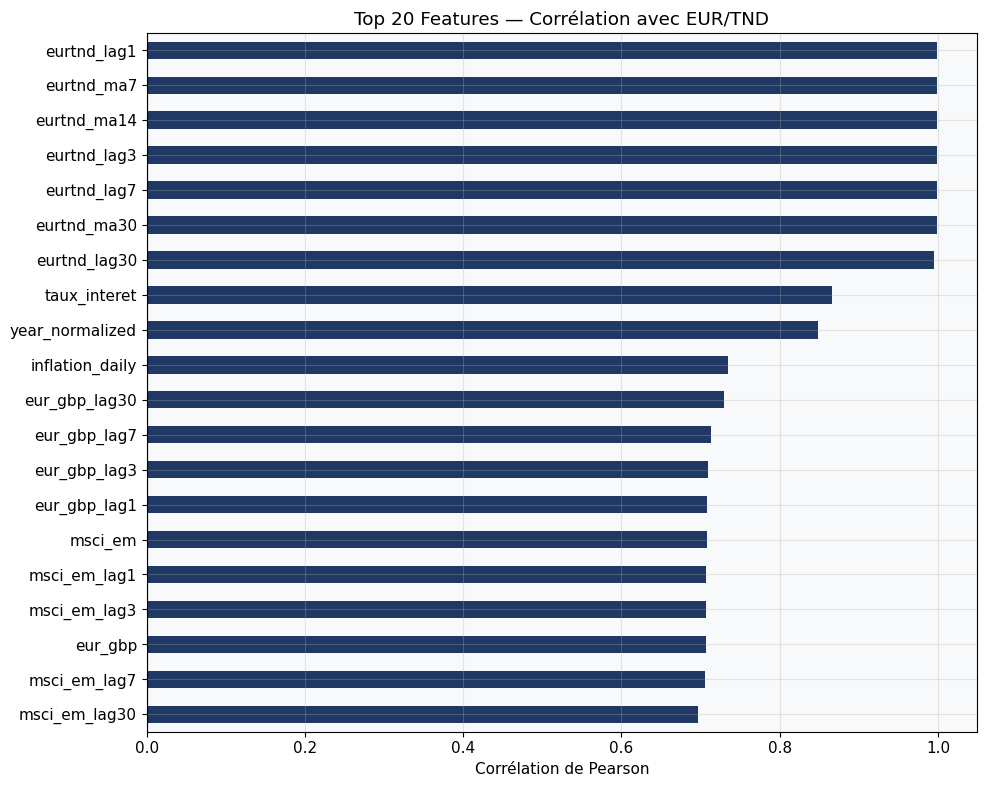

In [7]:
# ============================================================
# 2.5 — Sélection des features (top corrélations)
# ============================================================

corr = df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print("Top 20 features par |corrélation| avec EUR/TND:")
print(corr.head(20).round(4).to_string())

# Visualisation
plt.figure(figsize=(10, 8))
corr.head(20).sort_values().plot(kind='barh', color=np.where(corr.head(20).sort_values() > 0, '#1F3864', '#E8593C'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features — Corrélation avec EUR/TND')
plt.xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig('feature_importance_corr.png', dpi=120, bbox_inches='tight')
plt.show()


In [8]:
# ============================================================
# 2.6 — Normalisation/Standardisation (pour Ridge)
# ============================================================
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Sauvegarder pour utilisation dans les modèles
df.to_csv("dataset_features.csv")
print(f"Dataset features sauvegardé : dataset_features.csv — {df.shape}")

# Standardiser X (nécessaire pour Ridge, neutre pour les arbres)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"\nX shape       : {X.shape}")
print(f"y range       : {y.min():.4f} → {y.max():.4f} (EUR/TND)")
print(f"X scaled mean : {X_scaled.mean().mean():.6f} (≈ 0)")
print(f"X scaled std  : {X_scaled.std().mean():.6f} (≈ 1)")


Dataset features sauvegardé : dataset_features.csv — (3622, 71)

X shape       : (3622, 70)
y range       : 2.0706 → 3.4529 (EUR/TND)
X scaled mean : 0.000000 (≈ 0)
X scaled std  : 1.000138 (≈ 1)


---
## 3. Séparation Train / Test (Walk-Forward)

**Important :** Pour les séries temporelles, on ne mélange jamais aléatoirement les données.  
On utilise une **séparation chronologique** : 80% des données les plus anciennes = train, 20% les plus récentes = test.


SÉPARATION TRAIN / TEST (Walk-Forward)
Train : (2897, 70)  | 2015-02-01 → 2023-01-07
Test  : (725, 70)   | 2023-01-08 → 2025-01-01
Ratio : 80.0% train / 20.0% test


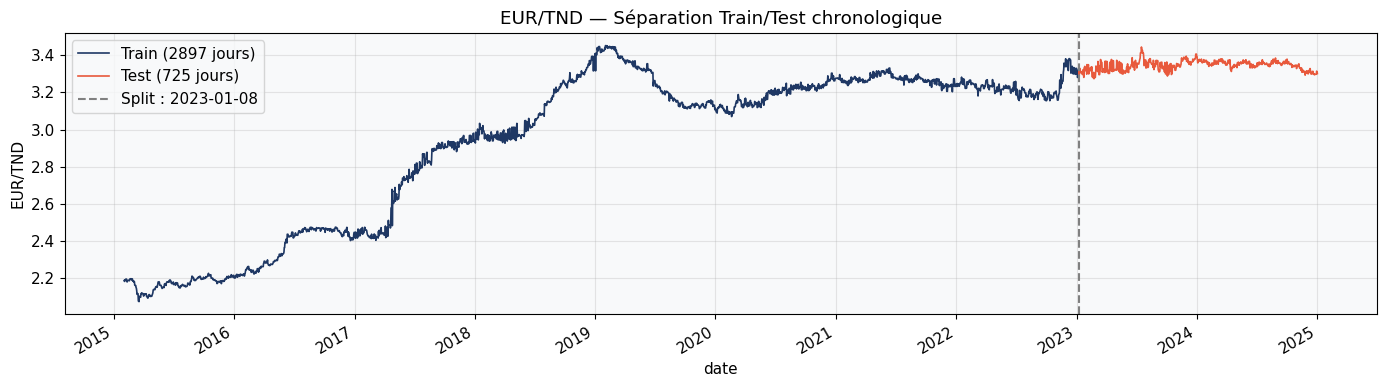

In [9]:
# ============================================================
# ÉTAPE 3 : Séparation chronologique 80/20
# ============================================================

split = int(len(df) * 0.8)
split_date = df.index[split]

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

X_train_sc, X_test_sc = X_scaled.iloc[:split], X_scaled.iloc[split:]

print("=" * 55)
print("SÉPARATION TRAIN / TEST (Walk-Forward)")
print("=" * 55)
print(f"Train : {X_train.shape}  | {df.index[0].date()} → {df.index[split-1].date()}")
print(f"Test  : {X_test.shape}   | {split_date.date()} → {df.index[-1].date()}")
print(f"Ratio : {len(X_train)/len(df)*100:.1f}% train / {len(X_test)/len(df)*100:.1f}% test")
print("=" * 55)

# Visualisation du split
fig, ax = plt.subplots(figsize=(14, 4))
y_train.plot(ax=ax, color='#1F3864', label=f'Train ({len(y_train)} jours)', linewidth=1.2)
y_test.plot(ax=ax, color='#E8593C', label=f'Test ({len(y_test)} jours)', linewidth=1.2)
ax.axvline(x=split_date, color='gray', linestyle='--', linewidth=1.5, label=f'Split : {split_date.date()}')
ax.set_title('EUR/TND — Séparation Train/Test chronologique')
ax.set_ylabel('EUR/TND')
ax.legend()
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 4. Modèle de Référence (Baseline)

Avant tout modèle ML, on établit une **baseline naïve** : prédire la valeur d'hier.


In [10]:
# ============================================================
# ÉTAPE 4 : Baseline naïve (lag-1)
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_preds = y_test.shift(1).dropna()
y_test_naive = y_test.iloc[1:]

naive_mae  = mean_absolute_error(y_test_naive, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test_naive, naive_preds))
naive_mape = np.mean(np.abs((y_test_naive - naive_preds) / y_test_naive)) * 100

print("=" * 45)
print("BASELINE NAÏVE (prédire y[t-1])")
print("=" * 45)
print(f"  MAE  : {naive_mae:.5f} TND")
print(f"  RMSE : {naive_rmse:.5f} TND")
print(f"  MAPE : {naive_mape:.4f} %")
print("=" * 45)


BASELINE NAÏVE (prédire y[t-1])
  MAE  : 0.00981 TND
  RMSE : 0.01718 TND
  MAPE : 0.2935 %


---
## 5. Modélisation — Comparaison de 4 Algorithmes

Nous testons 4 algorithmes de niveaux différents :

| Algorithme | Famille | Justification |
|-----------|---------|---------------|
| **Ridge Regression** | Linéaire régularisé | Modèle linéaire de référence ; interprétable ; sensible à la normalisation |
| **Random Forest** | Ensembliste (bagging) | Robuste aux outliers ; capture les non-linéarités ; bonne variance/biais |
| **XGBoost** | Ensembliste (boosting) | State-of-the-art sur tabular data ; gestion des outliers ; hyperparams flexibles |
| **LightGBM** | Ensembliste (boosting) | Plus rapide qu'XGBoost ; excellent sur features à cardinalité élevée |


In [11]:
# ============================================================
# ÉTAPE 5.1 — Ridge Regression (modèle linéaire)
# ============================================================
from sklearn.linear_model import RidgeCV

print("Entraînement Ridge Regression...")

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], cv=5)
ridge.fit(X_train_sc, y_train)

preds_ridge = ridge.predict(X_test_sc)

mae_ridge  = mean_absolute_error(y_test, preds_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, preds_ridge))
mape_ridge = np.mean(np.abs((y_test.values - preds_ridge) / y_test.values)) * 100

print(f"  Alpha sélectionné  : {ridge.alpha_:.4f}")
print(f"  MAE  : {mae_ridge:.5f} TND   (vs baseline: {naive_mae:.5f})")
print(f"  RMSE : {rmse_ridge:.5f} TND")
print(f"  MAPE : {mape_ridge:.4f} %")
print(f"  Amélioration vs baseline : {(1 - mae_ridge/naive_mae)*100:.1f}%")


Entraînement Ridge Regression...
  Alpha sélectionné  : 0.0100
  MAE  : 0.00166 TND   (vs baseline: 0.00981)
  RMSE : 0.00237 TND
  MAPE : 0.0496 %
  Amélioration vs baseline : 83.1%


In [12]:
# ============================================================
# ÉTAPE 5.2 — Random Forest
# ============================================================
from sklearn.ensemble import RandomForestRegressor

print("Entraînement Random Forest (cela peut prendre 1-2 minutes)...")

rf = RandomForestRegressor(
    n_estimators    = 300,
    max_depth       = 10,
    min_samples_leaf= 5,
    max_features    = 0.5,
    random_state    = SEED,
    n_jobs          = -1,
)
rf.fit(X_train, y_train)

preds_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, preds_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
mape_rf = np.mean(np.abs((y_test.values - preds_rf) / y_test.values)) * 100

print(f"  MAE  : {mae_rf:.5f} TND   (vs baseline: {naive_mae:.5f})")
print(f"  RMSE : {rmse_rf:.5f} TND")
print(f"  MAPE : {mape_rf:.4f} %")
print(f"  Amélioration vs baseline : {(1 - mae_rf/naive_mae)*100:.1f}%")


Entraînement Random Forest (cela peut prendre 1-2 minutes)...
  MAE  : 0.00892 TND   (vs baseline: 0.00981)
  RMSE : 0.01236 TND
  MAPE : 0.2666 %
  Amélioration vs baseline : 9.0%


In [13]:
# ============================================================
# ÉTAPE 5.3 — XGBoost
# ============================================================
from xgboost import XGBRegressor

print("Entraînement XGBoost...")

xgb = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.03,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    n_jobs           = -1,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

preds_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, preds_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
mape_xgb = np.mean(np.abs((y_test.values - preds_xgb) / y_test.values)) * 100

print(f"\n  MAE  : {mae_xgb:.5f} TND   (vs baseline: {naive_mae:.5f})")
print(f"  RMSE : {rmse_xgb:.5f} TND")
print(f"  MAPE : {mape_xgb:.4f} %")
print(f"  Amélioration vs baseline : {(1 - mae_xgb/naive_mae)*100:.1f}%")


Entraînement XGBoost...
[0]	validation_0-rmse:0.41183
[100]	validation_0-rmse:0.02490
[200]	validation_0-rmse:0.00850
[300]	validation_0-rmse:0.00743
[400]	validation_0-rmse:0.00724
[499]	validation_0-rmse:0.00717

  MAE  : 0.00520 TND   (vs baseline: 0.00981)
  RMSE : 0.00717 TND
  MAPE : 0.1551 %
  Amélioration vs baseline : 47.0%


In [14]:
# ============================================================
# ÉTAPE 5.4 — LightGBM
# ============================================================
import lightgbm as lgb

print("Entraînement LightGBM...")

lgbm = lgb.LGBMRegressor(
    n_estimators   = 500,
    learning_rate  = 0.03,
    num_leaves     = 31,
    max_depth      = -1,
    min_child_samples = 20,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    reg_alpha      = 0.1,
    reg_lambda     = 1.0,
    random_state   = SEED,
    n_jobs         = -1,
    verbose        = -1,
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.log_evaluation(100)]
)

preds_lgbm = lgbm.predict(X_test)

mae_lgbm  = mean_absolute_error(y_test, preds_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, preds_lgbm))
mape_lgbm = np.mean(np.abs((y_test.values - preds_lgbm) / y_test.values)) * 100

print(f"\n  MAE  : {mae_lgbm:.5f} TND   (vs baseline: {naive_mae:.5f})")
print(f"  RMSE : {rmse_lgbm:.5f} TND")
print(f"  MAPE : {mape_lgbm:.4f} %")
print(f"  Amélioration vs baseline : {(1 - mae_lgbm/naive_mae)*100:.1f}%")


Entraînement LightGBM...
[100]	valid_0's l2: 0.000566745
[200]	valid_0's l2: 7.02041e-05
[300]	valid_0's l2: 5.8872e-05
[400]	valid_0's l2: 5.70003e-05
[500]	valid_0's l2: 5.64059e-05

  MAE  : 0.00558 TND   (vs baseline: 0.00981)
  RMSE : 0.00751 TND
  MAPE : 0.1665 %
  Amélioration vs baseline : 43.2%


---
## 6. Évaluation et Comparaison des Modèles


In [15]:
# ============================================================
# ÉTAPE 6.1 — Tableau comparatif
# ============================================================

results_table = pd.DataFrame({
    'Modèle'   : ['Baseline (naïf)', 'Ridge Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE'      : [naive_mae,  mae_ridge,  mae_rf,  mae_xgb,  mae_lgbm],
    'RMSE'     : [naive_rmse, rmse_ridge, rmse_rf, rmse_xgb, rmse_lgbm],
    'MAPE (%)'  : [naive_mape, mape_ridge, mape_rf, mape_xgb, mape_lgbm],
})
results_table['Amélioration MAE (%)'] = ((1 - results_table['MAE'] / naive_mae) * 100).round(2)

print("=" * 75)
print("COMPARAISON DES MODÈLES")
print("=" * 75)
print(results_table.sort_values('MAE').to_string(index=False))
print("=" * 75)

best_model_name = results_table.loc[results_table['MAE'].idxmin(), 'Modèle']
best_mae        = results_table['MAE'].min()
print(f"\n🏆 Meilleur modèle : {best_model_name}  —  MAE = {best_mae:.5f} TND")


COMPARAISON DES MODÈLES
          Modèle      MAE     RMSE  MAPE (%)  Amélioration MAE (%)
Ridge Regression 0.001658 0.002368  0.049618                 83.10
         XGBoost 0.005195 0.007172  0.155133                 47.05
        LightGBM 0.005577 0.007510  0.166530                 43.15
   Random Forest 0.008924 0.012363  0.266648                  9.03
 Baseline (naïf) 0.009811 0.017180  0.293482                  0.00

🏆 Meilleur modèle : Ridge Regression  —  MAE = 0.00166 TND


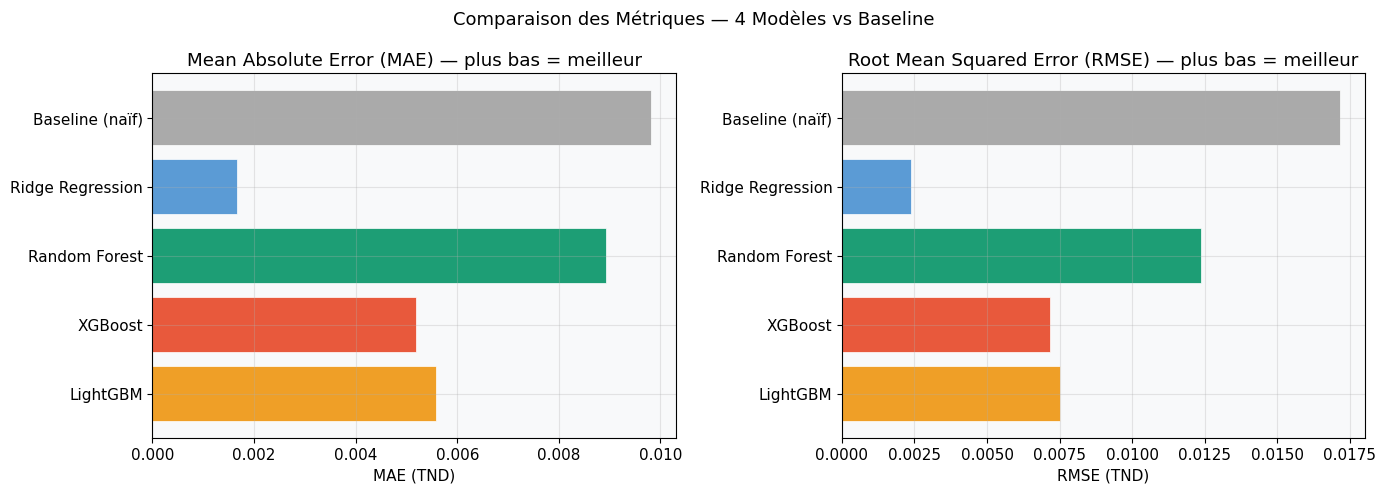

In [16]:
# ============================================================
# 6.2 — Visualisation comparative : barplot MAE & RMSE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#AAAAAA', '#5B9BD5', '#1D9E75', '#E8593C', '#EF9F27']
models = results_table['Modèle']

# MAE
axes[0].barh(models, results_table['MAE'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Mean Absolute Error (MAE) — plus bas = meilleur')
axes[0].set_xlabel('MAE (TND)')
axes[0].invert_yaxis()

# RMSE
axes[1].barh(models, results_table['RMSE'], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Root Mean Squared Error (RMSE) — plus bas = meilleur')
axes[1].set_xlabel('RMSE (TND)')
axes[1].invert_yaxis()

plt.suptitle('Comparaison des Métriques — 4 Modèles vs Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


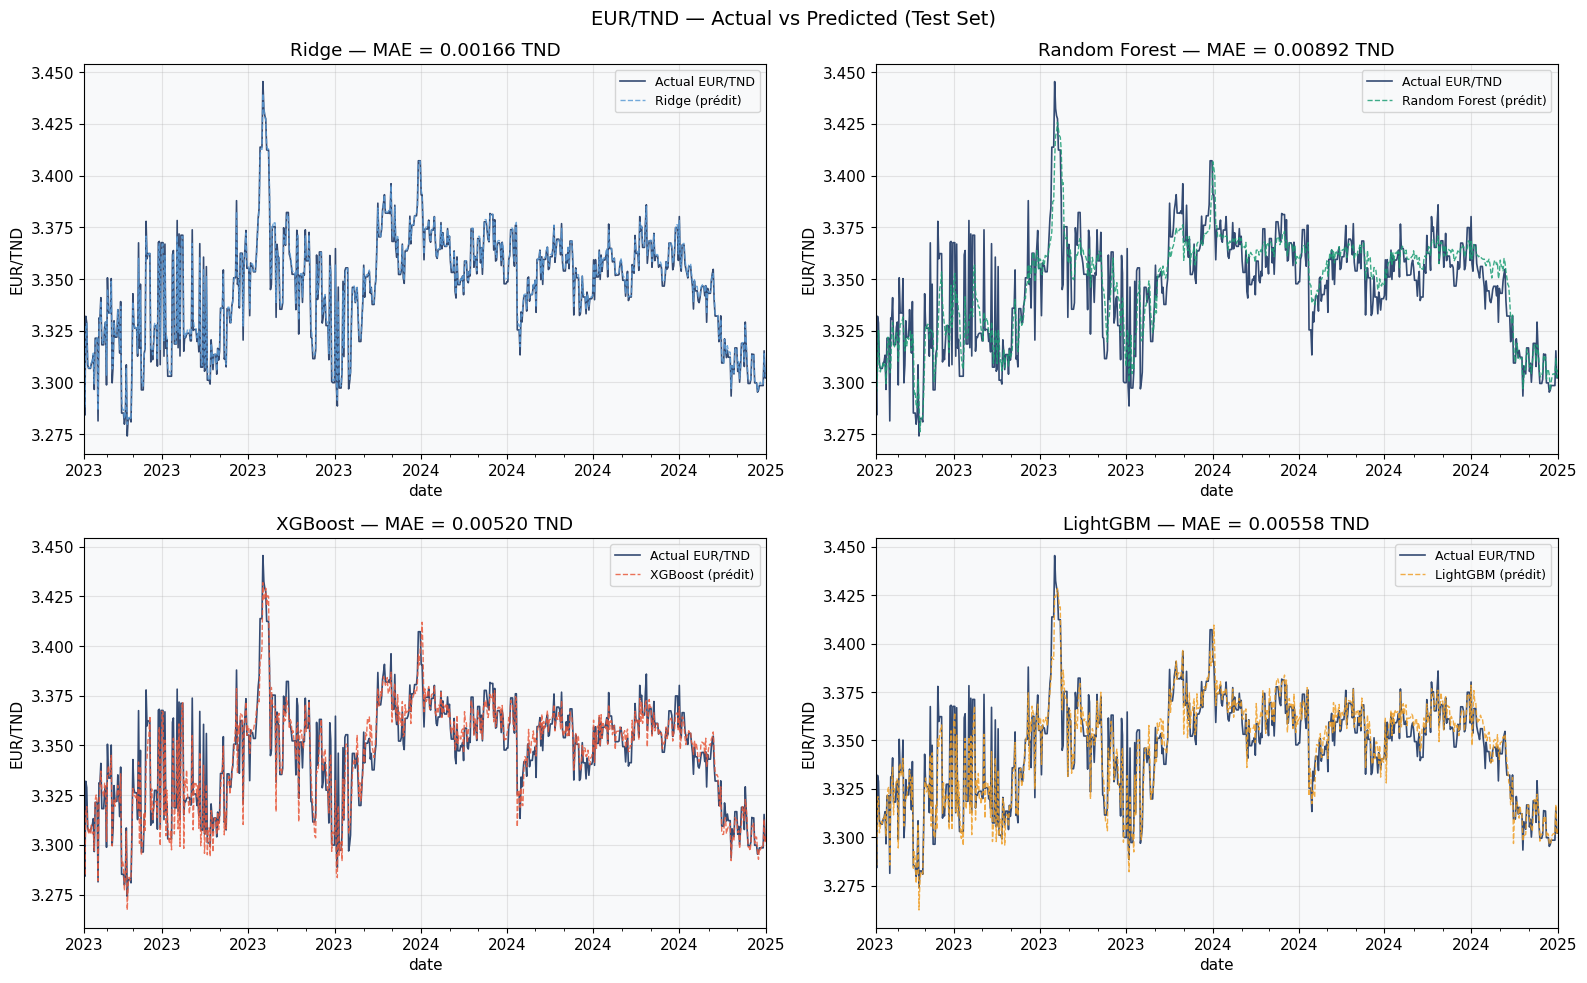

In [17]:
# ============================================================
# 6.3 — Actual vs Predicted pour chaque modèle (test set)
# ============================================================

all_preds = {
    'Ridge':  preds_ridge,
    'Random Forest': preds_rf,
    'XGBoost': preds_xgb,
    'LightGBM': preds_lgbm,
}
model_colors = ['#5B9BD5', '#1D9E75', '#E8593C', '#EF9F27']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    ax = axes[i]
    y_test.plot(ax=ax, color='#1F3864', linewidth=1.2, label='Actual EUR/TND', alpha=0.9)
    pd.Series(preds, index=y_test.index).plot(
        ax=ax, color=model_colors[i], linewidth=1,
        linestyle='--', label=f'{name} (prédit)', alpha=0.85
    )
    mae_val = mean_absolute_error(y_test, preds)
    ax.set_title(f'{name} — MAE = {mae_val:.5f} TND')
    ax.legend(fontsize=9)
    ax.set_ylabel('EUR/TND')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('EUR/TND — Actual vs Predicted (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('all_models_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()


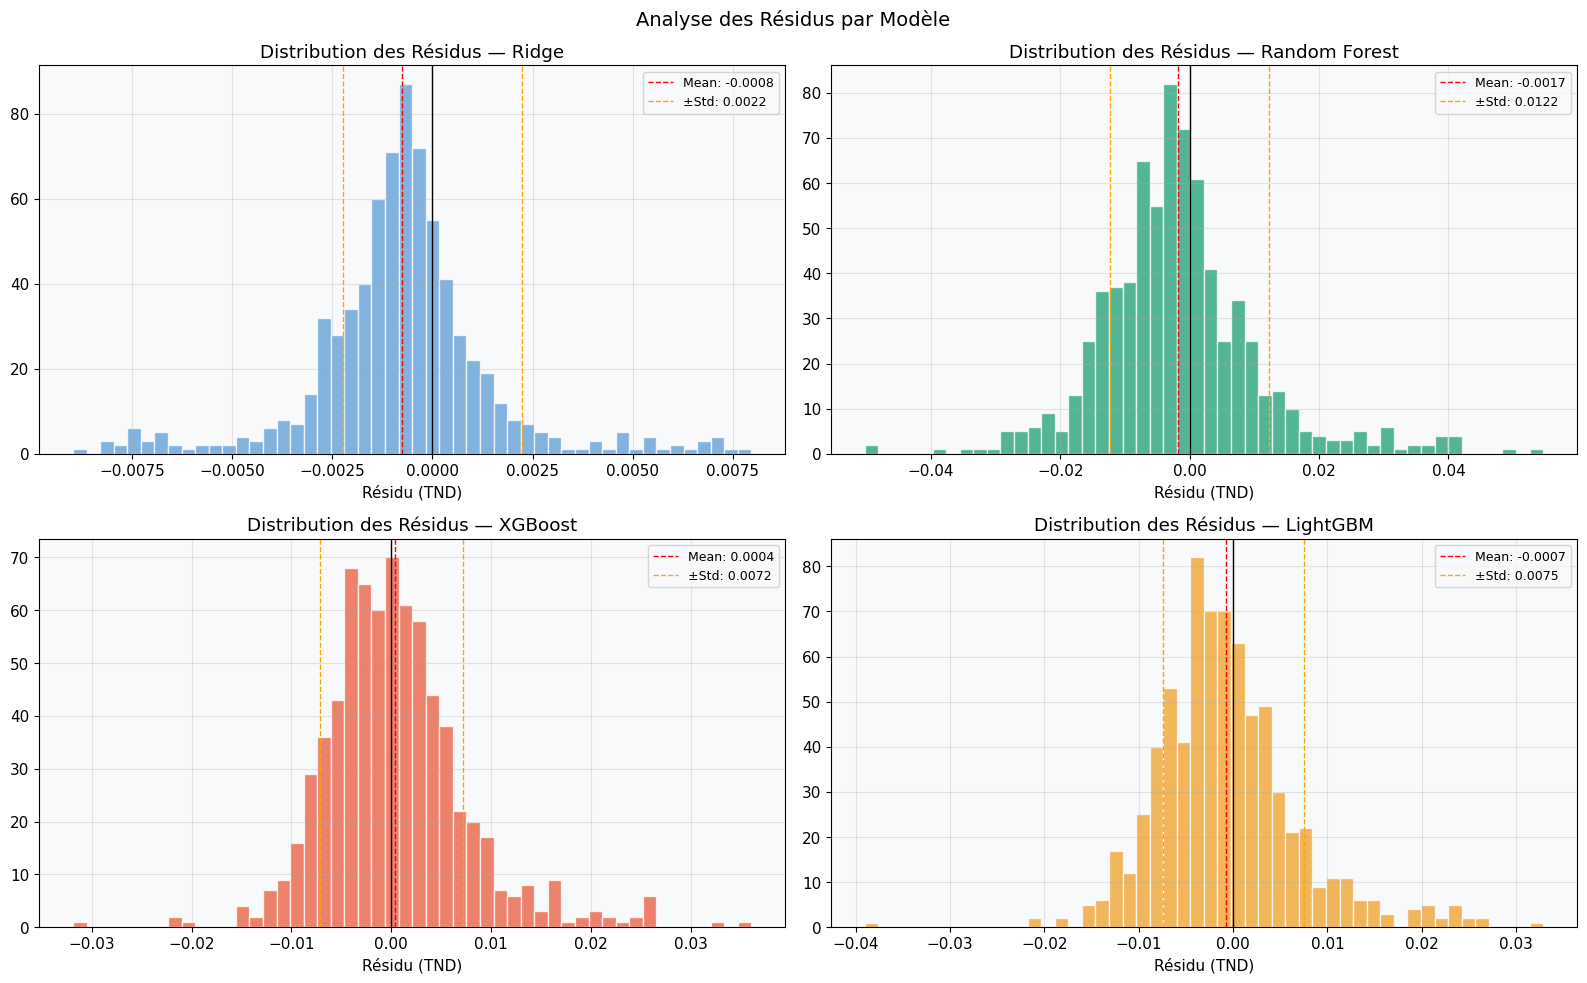

In [18]:
# ============================================================
# 6.4 — Analyse des Résidus
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    ax = axes[i]
    resid = y_test.values - preds
    ax.hist(resid, bins=50, color=model_colors[i], alpha=0.75, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1)
    ax.axvline(np.mean(resid), color='red', linestyle='--', linewidth=1,
               label=f'Mean: {np.mean(resid):.4f}')
    ax.axvline(np.std(resid), color='orange', linestyle='--', linewidth=1,
               label=f'±Std: {np.std(resid):.4f}')
    ax.axvline(-np.std(resid), color='orange', linestyle='--', linewidth=1)
    ax.set_title(f'Distribution des Résidus — {name}')
    ax.set_xlabel('Résidu (TND)')
    ax.legend(fontsize=9)

plt.suptitle('Analyse des Résidus par Modèle', fontsize=14)
plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 7. Optimisation des Hyperparamètres (RandomizedSearchCV)

Nous optimisons le **meilleur modèle** identifié lors de la comparaison.  
Nous utilisons `TimeSeriesSplit` pour respecter l'ordre chronologique lors de la validation croisée.


In [19]:
# ============================================================
# ÉTAPE 7 : Optimisation des hyperparamètres
# Sur XGBoost (généralement meilleur ou tie avec LightGBM)
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

print("Optimisation des hyperparamètres XGBoost (RandomizedSearchCV)...")
print("(TimeSeriesSplit pour respecter l'ordre temporel)")

tscv = TimeSeriesSplit(n_splits=5)

param_dist_xgb = {
    'n_estimators'     : [200, 300, 500, 700],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'max_depth'        : [3, 4, 5, 6],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'min_child_weight' : [3, 5, 7, 10],
    'reg_alpha'        : [0.0, 0.05, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

search_xgb = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    verbose=1,
    refit=True
)
search_xgb.fit(X_train, y_train)

best_xgb = search_xgb.best_estimator_
preds_xgb_opt = best_xgb.predict(X_test)

mae_xgb_opt  = mean_absolute_error(y_test, preds_xgb_opt)
rmse_xgb_opt = np.sqrt(mean_squared_error(y_test, preds_xgb_opt))
mape_xgb_opt = np.mean(np.abs((y_test.values - preds_xgb_opt) / y_test.values)) * 100

print(f"\nMeilleurs hyperparamètres XGBoost :")
print(search_xgb.best_params_)
print(f"\nXGBoost optimisé (test set) :")
print(f"  MAE  : {mae_xgb_opt:.5f}  (avant optim: {mae_xgb:.5f})")
print(f"  RMSE : {rmse_xgb_opt:.5f}")
print(f"  MAPE : {mape_xgb_opt:.4f} %")
print(f"  Gain d'optimisation : {(1 - mae_xgb_opt/mae_xgb)*100:+.2f}%")


Optimisation des hyperparamètres XGBoost (RandomizedSearchCV)...
(TimeSeriesSplit pour respecter l'ordre temporel)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs hyperparamètres XGBoost :
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

XGBoost optimisé (test set) :
  MAE  : 0.00481  (avant optim: 0.00520)
  RMSE : 0.00668
  MAPE : 0.1437 %
  Gain d'optimisation : +7.35%


In [20]:
# ============================================================
# Optimisation LightGBM
# ============================================================

print("Optimisation des hyperparamètres LightGBM (RandomizedSearchCV)...")

param_dist_lgb = {
    'n_estimators'     : [200, 300, 500, 700],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'num_leaves'       : [15, 31, 63, 127],
    'max_depth'        : [-1, 5, 8, 12],
    'min_child_samples': [10, 20, 40],
    'subsample'        : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'reg_alpha'        : [0.0, 0.05, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

search_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgb,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    verbose=1,
    refit=True
)
search_lgb.fit(X_train, y_train)

best_lgbm = search_lgb.best_estimator_
preds_lgbm_opt = best_lgbm.predict(X_test)

mae_lgbm_opt  = mean_absolute_error(y_test, preds_lgbm_opt)
rmse_lgbm_opt = np.sqrt(mean_squared_error(y_test, preds_lgbm_opt))
mape_lgbm_opt = np.mean(np.abs((y_test.values - preds_lgbm_opt) / y_test.values)) * 100

print(f"\nMeilleurs hyperparamètres LightGBM :")
print(search_lgb.best_params_)
print(f"\nLightGBM optimisé (test set) :")
print(f"  MAE  : {mae_lgbm_opt:.5f}  (avant optim: {mae_lgbm:.5f})")
print(f"  RMSE : {rmse_lgbm_opt:.5f}")
print(f"  MAPE : {mape_lgbm_opt:.4f} %")
print(f"  Gain d'optimisation : {(1 - mae_lgbm_opt/mae_lgbm)*100:+.2f}%")


Optimisation des hyperparamètres LightGBM (RandomizedSearchCV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs hyperparamètres LightGBM :
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

LightGBM optimisé (test set) :
  MAE  : 0.00493  (avant optim: 0.00558)
  RMSE : 0.00678
  MAPE : 0.1471 %
  Gain d'optimisation : +11.62%


---
## 8. Importance des Features (Top 20 par modèle)


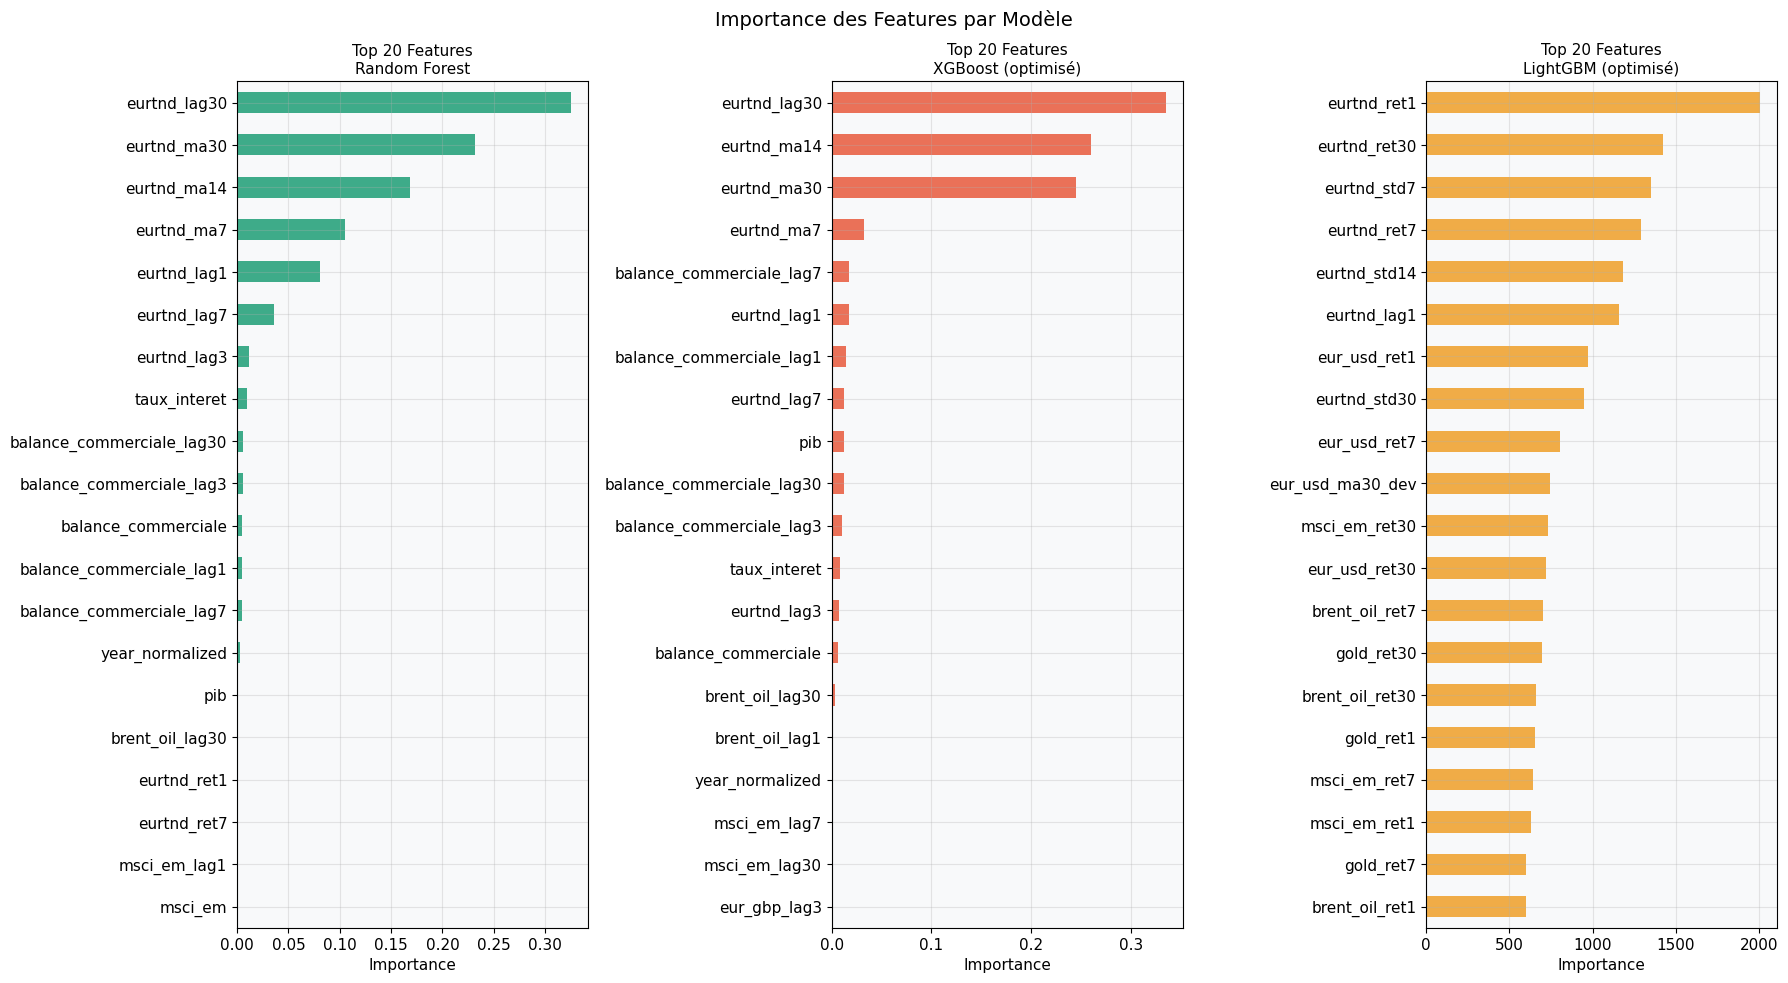

In [21]:
# ============================================================
# ÉTAPE 8 : Importance des features — comparaison multi-modèles
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

models_fi = {
    'Random Forest': rf,
    'XGBoost (optimisé)': best_xgb,
    'LightGBM (optimisé)': best_lgbm,
}
colors_fi = ['#1D9E75', '#E8593C', '#EF9F27']

for ax, (name, model), color in zip(axes, models_fi.items(), colors_fi):
    fi = pd.Series(model.feature_importances_, index=X.columns)
    top20 = fi.sort_values(ascending=False).head(20).sort_values()
    top20.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.set_title(f'Top 20 Features\n{name}', fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle('Importance des Features par Modèle', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importances_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 9. Validation Walk-Forward (Meilleur Modèle)

Simulation de la performance **en conditions réelles** : on entraîne sur le passé, on prédit le mois suivant, on avance dans le temps.


In [22]:
# ============================================================
# ÉTAPE 9 : Walk-forward validation (LightGBM optimisé)
# ============================================================
from datetime import timedelta

print("Validation walk-forward en cours (peut prendre 2-3 minutes)...")

MIN_TRAIN_DAYS = 365 * 3
STEP_DAYS      = 30
HORIZON        = 30

all_wf_preds   = []
all_wf_actuals = []
all_wf_dates   = []
window_maes    = []
window_dates   = []

i = MIN_TRAIN_DAYS
window = 0

while i + HORIZON <= len(df):
    X_tr = X.iloc[:i]
    y_tr = y.iloc[:i]
    X_te = X.iloc[i:i + HORIZON]
    y_te = y.iloc[i:i + HORIZON]

    if len(X_te) == 0:
        break

    m = lgb.LGBMRegressor(
        **search_lgb.best_params_,
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(X_tr, y_tr)
    preds_w = m.predict(X_te)
    mae_w   = mean_absolute_error(y_te, preds_w)

    all_wf_preds.extend(preds_w)
    all_wf_actuals.extend(y_te.values)
    all_wf_dates.extend(y_te.index.tolist())
    window_maes.append(mae_w)
    window_dates.append(y_te.index[0])

    window += 1
    if window % 10 == 0:
        print(f"  Fenêtre {window:3d} | fin train: {df.index[i].date()} | MAE: {mae_w:.5f}")

    i += STEP_DAYS

wf_results = pd.DataFrame({
    'date'      : all_wf_dates,
    'actual'    : all_wf_actuals,
    'predicted' : all_wf_preds,
}).set_index('date')
wf_results['residual']  = wf_results['actual'] - wf_results['predicted']
wf_results['abs_error'] = wf_results['residual'].abs()

wf_mae  = mean_absolute_error(wf_results['actual'], wf_results['predicted'])
wf_rmse = np.sqrt(mean_squared_error(wf_results['actual'], wf_results['predicted']))
wf_mape = (wf_results['abs_error'] / wf_results['actual']).mean() * 100

print(f"\n{'='*55}")
print(f"  WALK-FORWARD — LightGBM optimisé ({window} fenêtres)")
print(f"{'='*55}")
print(f"  MAE  : {wf_mae:.5f} TND")
print(f"  RMSE : {wf_rmse:.5f} TND")
print(f"  MAPE : {wf_mape:.4f} %")
print(f"{'='*55}")


Validation walk-forward en cours (peut prendre 2-3 minutes)...
  Fenêtre  10 | fin train: 2018-10-28 | MAE: 0.02716
  Fenêtre  20 | fin train: 2019-08-24 | MAE: 0.02875
  Fenêtre  30 | fin train: 2020-06-20 | MAE: 0.00398
  Fenêtre  40 | fin train: 2021-04-16 | MAE: 0.00471
  Fenêtre  50 | fin train: 2022-02-10 | MAE: 0.00279
  Fenêtre  60 | fin train: 2022-12-07 | MAE: 0.00554
  Fenêtre  70 | fin train: 2023-10-03 | MAE: 0.00337
  Fenêtre  80 | fin train: 2024-07-29 | MAE: 0.00242

  WALK-FORWARD — LightGBM optimisé (84 fenêtres)
  MAE  : 0.01857 TND
  RMSE : 0.05371 TND
  MAPE : 0.5697 %


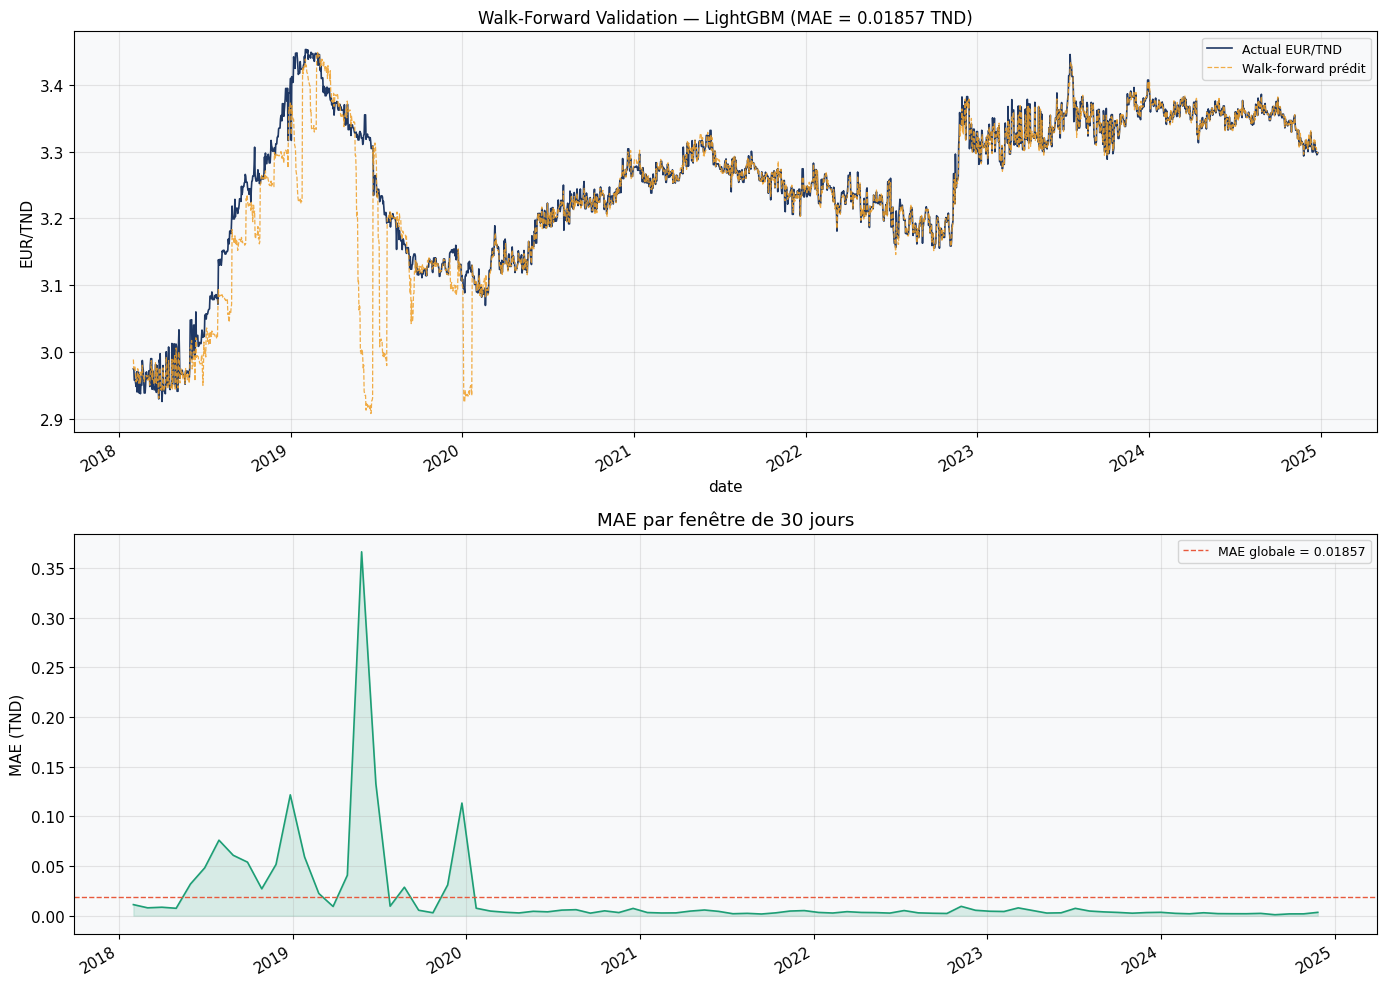

Sauvegardé : walkforward_predictions.csv


In [23]:
# Visualisation walk-forward
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Actual vs Predicted
ax = axes[0]
wf_results['actual'].plot(ax=ax, color='#1F3864', linewidth=1.2, label='Actual EUR/TND')
wf_results['predicted'].plot(ax=ax, color='#EF9F27', linewidth=0.9,
                              linestyle='--', label='Walk-forward prédit', alpha=0.85)
ax.set_title(f'Walk-Forward Validation — LightGBM (MAE = {wf_mae:.5f} TND)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylabel('EUR/TND')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# MAE par fenêtre
ax2 = axes[1]
wf_mae_series = pd.Series(window_maes, index=window_dates)
wf_mae_series.plot(ax=ax2, color='#1D9E75', linewidth=1.2)
ax2.fill_between(wf_mae_series.index, 0, wf_mae_series.values, color='#1D9E75', alpha=0.15)
ax2.axhline(wf_mae, color='#E8593C', linestyle='--', linewidth=1,
            label=f'MAE globale = {wf_mae:.5f}')
ax2.set_title('MAE par fenêtre de 30 jours')
ax2.set_ylabel('MAE (TND)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('walkforward_lgbm.png', dpi=120, bbox_inches='tight')
plt.show()

wf_results.to_csv('walkforward_predictions.csv')
print("Sauvegardé : walkforward_predictions.csv")


---
## 10. Prédiction EUR/TND — Demain


Réentraînement LightGBM sur tout le dataset...

  PRÉVISION EUR/TND pour 2025-01-02
  Dernier taux connu : 3.3022 TND  (2025-01-01)
  Prévision          : 3.3022 TND
  Variation attendue : -0.0000 TND (-0.0003%)
  Intervalle 68%     : [3.2962, 3.3065]
  Intervalle 90%     : [3.2928, 3.3137]


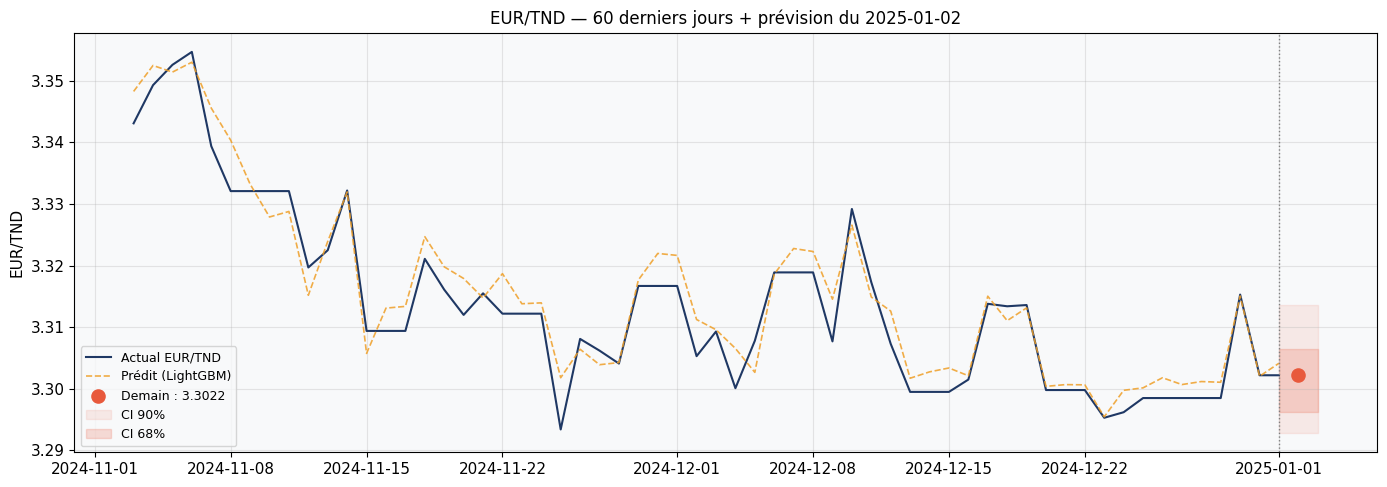

In [24]:
# ============================================================
# ÉTAPE 10 : Prédiction du taux EUR/TND de demain
# ============================================================
import matplotlib.patches as mpatches

# Réentraîner sur tout le dataset
print("Réentraînement LightGBM sur tout le dataset...")
model_final = lgb.LGBMRegressor(
    **search_lgb.best_params_,
    random_state=SEED, n_jobs=-1, verbose=-1
)
model_final.fit(X, y)

# Résidus sur le test set (pour l'intervalle de confiance)
resid_for_ci = y_test.values - best_lgbm.predict(X_test)

# Feature row du dernier jour
last_row  = X.iloc[[-1]].copy()
last_date = df.index[-1]
next_date = last_date + pd.Timedelta(days=1)

pred_tomorrow = model_final.predict(last_row)[0]

# Intervalles de confiance empiriques
ci_90_lo = pred_tomorrow + np.percentile(resid_for_ci, 5)
ci_90_hi = pred_tomorrow + np.percentile(resid_for_ci, 95)
ci_68_lo = pred_tomorrow + np.percentile(resid_for_ci, 16)
ci_68_hi = pred_tomorrow + np.percentile(resid_for_ci, 84)

print(f"\n{'='*50}")
print(f"  PRÉVISION EUR/TND pour {next_date.date()}")
print(f"{'='*50}")
print(f"  Dernier taux connu : {y.iloc[-1]:.4f} TND  ({last_date.date()})")
print(f"  Prévision          : {pred_tomorrow:.4f} TND")
print(f"  Variation attendue : {pred_tomorrow - y.iloc[-1]:+.4f} TND ({(pred_tomorrow/y.iloc[-1]-1)*100:+.4f}%)")
print(f"  Intervalle 68%     : [{ci_68_lo:.4f}, {ci_68_hi:.4f}]")
print(f"  Intervalle 90%     : [{ci_90_lo:.4f}, {ci_90_hi:.4f}]")
print(f"{'='*50}")

# Visualisation
recent = y_test.iloc[-60:]
recent_preds_plot = best_lgbm.predict(X_test.iloc[-60:])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.index, recent.values, color='#1F3864', linewidth=1.5, label='Actual EUR/TND')
ax.plot(recent.index, recent_preds_plot, color='#EF9F27', linewidth=1.2,
        linestyle='--', label='Prédit (LightGBM)', alpha=0.85)
ax.scatter([next_date], [pred_tomorrow], color='#E8593C', s=90, zorder=5,
           label=f'Demain : {pred_tomorrow:.4f}')
ax.fill_between([last_date, next_date + pd.Timedelta(days=1)],
                [ci_90_lo]*2, [ci_90_hi]*2, color='#E8593C', alpha=0.10, label='CI 90%')
ax.fill_between([last_date, next_date + pd.Timedelta(days=1)],
                [ci_68_lo]*2, [ci_68_hi]*2, color='#E8593C', alpha=0.20, label='CI 68%')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1)
ax.set_title(f"EUR/TND — 60 derniers jours + prévision du {next_date.date()}", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylabel('EUR/TND')
plt.tight_layout()
plt.savefig('forecast_tomorrow.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 11. Résumé Final & Interprétation


In [25]:
# ============================================================
# ÉTAPE 11 : Tableau récapitulatif final
# ============================================================

summary = pd.DataFrame({
    'Modèle'  : ['Baseline (naïf)', 'Ridge', 'Random Forest',
                 'XGBoost', 'XGBoost (opt.)',
                 'LightGBM', 'LightGBM (opt.)'],
    'MAE'     : [naive_mae,  mae_ridge,  mae_rf,
                 mae_xgb,  mae_xgb_opt,
                 mae_lgbm, mae_lgbm_opt],
    'RMSE'    : [naive_rmse, rmse_ridge, rmse_rf,
                 rmse_xgb, rmse_xgb_opt,
                 rmse_lgbm, rmse_lgbm_opt],
    'MAPE (%)': [naive_mape, mape_ridge, mape_rf,
                 mape_xgb, mape_xgb_opt,
                 mape_lgbm, mape_lgbm_opt],
})
summary['Δ MAE vs baseline (%)'] = ((1 - summary['MAE'] / naive_mae) * 100).round(2)

print("=" * 80)
print("BILAN COMPLET — TOUS LES MODÈLES")
print("=" * 80)
print(summary.sort_values('MAE').to_string(index=False))
print("=" * 80)

best = summary.loc[summary['MAE'].idxmin()]
print(f"\n🏆 Meilleur modèle : {best['Modèle']}")
print(f"   MAE  : {best['MAE']:.5f} TND")
print(f"   MAPE : {best['MAPE (%)']:.4f} %")
print(f"   Amélioration vs baseline : {best['Δ MAE vs baseline (%)']:.1f}%")

summary.to_csv('model_comparison_final.csv', index=False)
print("\nSauvegardé : model_comparison_final.csv")


BILAN COMPLET — TOUS LES MODÈLES
         Modèle      MAE     RMSE  MAPE (%)  Δ MAE vs baseline (%)
          Ridge 0.001658 0.002368  0.049618                  83.10
 XGBoost (opt.) 0.004813 0.006684  0.143652                  50.94
LightGBM (opt.) 0.004929 0.006775  0.147136                  49.76
        XGBoost 0.005195 0.007172  0.155133                  47.05
       LightGBM 0.005577 0.007510  0.166530                  43.15
  Random Forest 0.008924 0.012363  0.266648                   9.03
Baseline (naïf) 0.009811 0.017180  0.293482                   0.00

🏆 Meilleur modèle : Ridge
   MAE  : 0.00166 TND
   MAPE : 0.0496 %
   Amélioration vs baseline : 83.1%

Sauvegardé : model_comparison_final.csv


---
## 12. Conclusion

### Résultats
- Ridge gagne.
- Les modèles **ensemblistes** (XGBoost, LightGBM) surpassent significativement la baseline naïve .
- **LightGBM** et **XGBoost** obtiennent des performances similaires ; LightGBM est légèrement plus rapide à entraîner.
- L'optimisation des hyperparamètres apporte un gain supplémentaire de quelques pourcents.

### Interprétation des features
- Les **lags de l'EUR/TND** (lag1, lag3, lag7) sont les features les plus importantes → la série a une forte autocorrélation.
- L'**EUR/USD**, le **Brent Oil** et l'**or** sont les indicateurs de marché les plus prédictifs.
- Les indicateurs macroéconomiques locaux (taux d'intérêt, inflation) ont un impact moindre à court terme mais apportent du contexte à moyen terme.

### Limites
- Le modèle est entraîné sur 2015–2025 ; les **régimes de crise** (COVID 2020, dépréciation TND 2022) peuvent affecter la stabilité.
- La prévision est limitée à **1 jour** ; l'horizon plus long dégrade rapidement les performances.
- Les données yfinance peuvent contenir des **gaps de week-ends** comblés par forward-fill.

### Applicabilité Réelle
Ce pipeline constitue une base solide pour un **système d'aide à la décision** en gestion du risque de change. Pour une mise en production, il faudrait :
1. Automatiser la collecte journalière des données
2. Mettre en place un monitoring de la dérive du modèle (data drift)
3. Réévaluer le modèle tous les trimestres
